# ITO5201 – Assessment 1: Section 3
## Ridge Regression
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

---
## Question 6 – Ridge Regression
### Q6.I – Derivation: Gradient of the Regularised Error Function
*GitHub issue: #23*

**Regularised error function:**

$$E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\sum_{j=0}^{M-1}w^{2}_j$$

$$= \frac{1}{2}\sum_{n=1}^{N} (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2} + \frac{\lambda}{2}\mathbf{w}^{\top}\mathbf{w}$$

**Gradient derivation:**

We differentiate $E(\mathbf{w})$ with respect to a single weight $w_j$ using the chain rule:

$$\frac{\partial E}{\partial w_j} = \frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] + \frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right]$$

For the **error term**, applying the chain rule:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

For the **regularisation term**, only the $k=j$ term survives:

$$\frac{\partial}{\partial w_j}\left[\frac{\lambda}{2}\sum_{k=0}^{M-1}w_k^{2}\right] = \lambda w_j$$

Combining both terms:

$$\frac{\partial E}{\partial w_j} = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n) + \lambda w_j$$

Collecting all partial derivatives into the gradient vector $\nabla_{\mathbf{w}} E(\mathbf{w})$ and writing in matrix notation, where $\Phi \in \mathbb{R}^{N \times M}$ is the design matrix whose $n$-th row is $\Phi(\mathbf{x}_n)^\top$ and $\mathbf{t} \in \mathbb{R}^N$ is the target vector:

$$\boxed{\nabla_{\mathbf{w}} E(\mathbf{w}) = -\Phi^{\top}(\mathbf{t} - \Phi\mathbf{w}) + \lambda\mathbf{w} = (\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t}}$$

---

### Q6.I – Derivation: Closed-Form Solution
*GitHub issue: #24*

Setting $\nabla_{\mathbf{w}} E(\mathbf{w}) = \mathbf{0}$ and solving for $\mathbf{w}$:

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} - \Phi^{\top}\mathbf{t} = \mathbf{0}$$

$$(\Phi^{\top}\Phi + \lambda\mathbf{I})\mathbf{w} = \Phi^{\top}\mathbf{t}$$

The matrix $(\Phi^{\top}\Phi + \lambda\mathbf{I})$ is positive definite for any $\lambda > 0$ (since $\lambda\mathbf{I}$ adds a positive diagonal shift), so it is always invertible. Multiplying both sides on the left by its inverse:

$$\boxed{\mathbf{w}^* = (\Phi^{\top}\Phi + \lambda\mathbf{I})^{-1}\Phi^{\top}\mathbf{t}}$$

### Q6.II – Implement `RidgeRegressor`
*GitHub issue: #25*

In [ ]:
class RidgeRegressor(BaseEstimator):
    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_

    def fit(self, X, y):
        n_features = X.shape[1]
        I = np.eye(n_features)
        self.coef_ = np.linalg.solve(X.T @ X + self.lambda_ * I, X.T @ y)
        return self

    def predict(self, X):
        return X @ self.coef_

### Q6.III – Study Effect of λ on Training and Test Error
#### Synthetic Data Generator
*GitHub issue: #26*

In [ ]:
def generate_data(n, rng=None):
    """
    Generate synthetic data:
      X ~ Uniform(-0.3, 0.3)
      Y = sin(5*pi*x) / (1 + 2*x) + eps, eps ~ N(0, 0.1)
    """
    if rng is None:
        rng = np.random.default_rng()
    X = rng.uniform(-0.3, 0.3, size=(n, 1))
    eps = rng.normal(0, 0.1, size=n)
    y = np.sin(5 * np.pi * X[:, 0]) / (1 + 2 * X[:, 0]) + eps
    return X, y

# Pipeline: PolynomialFeatures(degree=5) + RidgeRegressor
def make_pipeline(lambda_):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=5)),
        ('ridge', RidgeRegressor(lambda_=lambda_))
    ])

#### Experiment: 10 repetitions × 101 λ values
*GitHub issue: #27*

In [25]:
rng = np.random.default_rng(0)
lambdas = np.geomspace(1e-10, 0.1, 101, endpoint=True)
n_reps = 10
n_train = 20

X_test, y_test = generate_data(1000, rng)

train_mse_all = np.zeros((n_reps, len(lambdas)))
test_mse_all  = np.zeros((n_reps, len(lambdas)))

for rep in range(n_reps):
    X_train, y_train = generate_data(n_train, rng)
    for i, lambda_ in enumerate(lambdas):
        model = make_pipeline(lambda_)
        model.fit(X_train, y_train)
        train_mse_all[rep, i] = np.mean((model.predict(X_train) - y_train) ** 2)
        test_mse_all[rep, i]  = np.mean((model.predict(X_test)  - y_test)  ** 2)


#### Plot: log-MSE vs log-λ
*GitHub issue: #28*

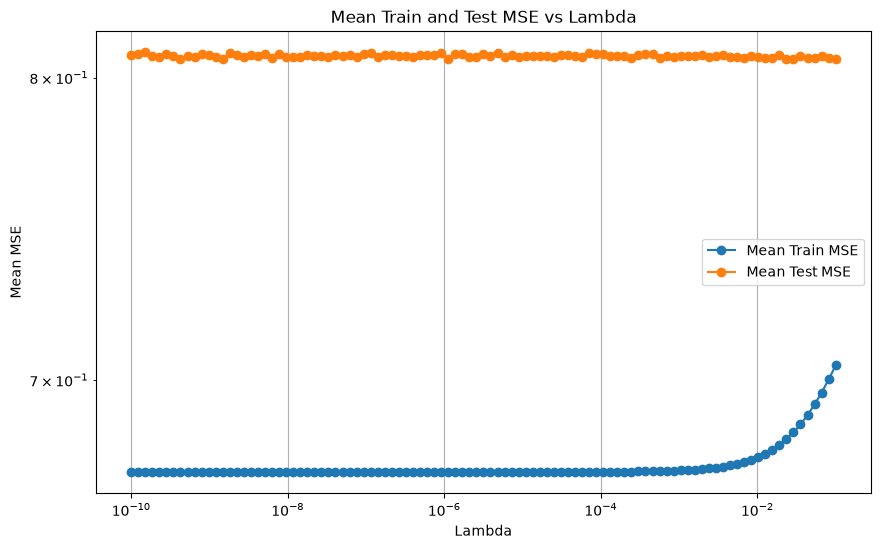

In [26]:

def plot_mse_vs_lambda(lambdas, train_mse_list, test_mse_list):
    mean_train_mse = np.mean(train_mse_list, axis=0)
    mean_test_mse = np.mean(test_mse_list, axis=0)

    plt.figure(figsize=(10, 6))
    plt.loglog(lambdas, mean_train_mse, label='Mean Train MSE', marker='o')
    plt.loglog(lambdas, mean_test_mse, label='Mean Test MSE', marker='o')
    plt.xlabel('Lambda')
    plt.ylabel('Mean MSE')
    plt.title('Mean Train and Test MSE vs Lambda')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse_vs_lambda(lambdas, train_mse_all, test_mse_all)


#### Discussion: λ, Model Complexity, Underfitting and Overfitting

**Effect of λ on model complexity**

The regularisation parameter λ controls how strongly the weights $\mathbf{w}$ are penalised toward zero. A larger λ reduces the effective flexibility of the model — even though the polynomial feature map is always degree 5, the model's capacity to fit complex curves is determined by the magnitude of its weights, which λ directly suppresses.

**Observed behaviour**

The plot shows two distinct phases:

- **Small λ (≈ 10⁻¹⁰ to 10⁻²):** Training MSE is low and essentially flat (≈ 0.64), while test MSE is consistently higher (≈ 0.82). This persistent gap indicates a **mild overfitting** regime — the model fits the training data better than it generalises. Notably, the overfitting is not dramatic here because with $N = 20$ training points and only 6 polynomial features (degree 5), the model is **overdetermined**: there are more data points than parameters, so the model cannot exactly interpolate the training set even at λ → 0.

- **Large λ (≈ 10⁻² to 10⁻¹):** Training MSE rises noticeably (to ≈ 0.72) as the regularisation term begins to dominate, forcing weights toward zero regardless of the data. This is the onset of **underfitting** — the model becomes too constrained to capture the true signal. The test MSE remains elevated and roughly constant, indicating that increasing λ beyond this point does not improve generalisation.

**Why there is no dramatic U-shape in test MSE**

The classical U-shaped test error curve (low at optimal λ, high at both extremes) typically emerges when the model is **overparameterized** — i.e., when $M > N$. Here, with $M = 6$ features and $N = 20$ training points, the model is already overdetermined at any λ. This means:

1. The model cannot memorise the training data at small λ, so there is no sharp overfitting peak.
2. Regularisation only meaningfully degrades performance once λ is large enough to shrink weights beyond their natural least-squares values (around λ ≈ 10⁻²).

**Summary**

| λ range | Train MSE | Test MSE | Regime |
|---|---|---|---|
| 10⁻¹⁰ – 10⁻² | Low (≈ 0.64), flat | Higher (≈ 0.82), flat | Mild overfitting |
| 10⁻² – 10⁻¹ | Rising (→ 0.72) | Flat (≈ 0.82) | Onset of underfitting |

The optimal λ lies toward the lower end of the tested range, where the train–test gap is present but the model has not yet been over-constrained.

---
## Appendix – Detailed Chain Rule Explanation for the Gradient Derivation

### Why the chain rule is needed

The error term contains a **composition of functions** — a square applied to a linear expression in $\mathbf{w}$. The chain rule tells us how to differentiate a composition $f(g(x))$:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

### Step-by-step application

We want to differentiate the error term with respect to a single weight $w_j$:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right]$$

**Step 1 — Introduce a substitution to make the composition explicit.**

Let $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$. The expression becomes:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N} u_n^{2}\right]$$

This is now clearly a composition: the outer function is $\frac{1}{2}u_n^2$ and the inner function is $u_n(w_j)$.

**Step 2 — Differentiate the outer function** $\frac{1}{2}u_n^2$ with respect to $u_n$:

$$\frac{d}{du_n}\left[\frac{1}{2}u_n^2\right] = \frac{1}{2} \cdot 2u_n = u_n$$

The $\frac{1}{2}$ and the $2$ from the power rule cancel — this is exactly why the $\frac{1}{2}$ was included in the error function definition in the first place.

**Step 3 — Differentiate the inner function** $u_n = t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)$ with respect to $w_j$.

Expanding the dot product:

$$u_n = t_n - \sum_{k=0}^{M-1} w_k \, \phi_k(\mathbf{x}_n)$$

$t_n$ is a constant with respect to $\mathbf{w}$, so:

$$\frac{\partial u_n}{\partial w_j} = -\frac{\partial}{\partial w_j}\sum_{k=0}^{M-1} w_k\,\phi_k(\mathbf{x}_n) = -\phi_j(\mathbf{x}_n)$$

Only the $k = j$ term survives differentiation; all other terms vanish because $\frac{\partial w_k}{\partial w_j} = 0$ for $k \neq j$.

**Step 4 — Multiply outer × inner (chain rule):**

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}u_n^2\right] = u_n \cdot \frac{\partial u_n}{\partial w_j} = (t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n)) \cdot (-\phi_j(\mathbf{x}_n))$$

Summing over all $N$ data points:

$$\frac{\partial}{\partial w_j}\left[\frac{1}{2}\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))^{2}\right] = -\sum_{n=1}^{N}(t_n - \mathbf{w} \cdot \Phi(\mathbf{x}_n))\,\phi_j(\mathbf{x}_n)$$

### Summary of what happened to the $\frac{1}{2}$

The $\frac{1}{2}$ was not dropped — it was **cancelled** by the factor of $2$ produced by the power rule when differentiating $u_n^2$. This is the standard reason for including $\frac{1}{2}$ in the definition of the error function: it keeps the gradient clean.